In [ ]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
from association import generate_rules


import geopandas as gpd
from mapclassify import classify

pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)

In [ ]:
basket_transaction_df = pd.read_pickle('../data/customer_basket_transactions.pkl')

basket_transaction_df.head()

,invoice_id,list_of_goods,customer_id,basket_size
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8


In [ ]:
customer_clusters = pd.read_csv('../data/customer_clusters.csv')

customer_clusters.head()

,customer_id,cluster_kmeans,cluster_name
0,3,2,Young Grocery
1,4,1,Vegetables-Hygiene Oriented
2,5,0,Older Long-Tenure Grocery
3,7,7,Service Sensitive
4,8,3,Tech Enthusiasts


Merging

We used how='inner' because only costumer's baskets that have a cluster assigned make sense.

In [ ]:
basket_with_clusters = pd.merge(basket_transaction_df, customer_clusters, on='customer_id', how='inner')

print(basket_with_clusters.shape)
basket_with_clusters.head()

(100000, 6)


,invoice_id,list_of_goods,customer_id,basket_size,cluster_kmeans,cluster_name
0,3700630,"[chicken, rice, pepper, whole wheat rice, shrimp, toothpaste, gums, cereals, bluetooth headphones, vacuum cleaner, body spray]",12912,11,4,Promotion Seekers
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12,4,Promotion Seekers
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7,6,Protein Enjoyers
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4,5,Large Families
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8,5,Large Families


Use a transaction split to mine rules on one subset and validate whether those rules also hold in a holdout subset.

In [ ]:
customers = basket_with_clusters[['customer_id', 'cluster_kmeans']].drop_duplicates()


train_customers, test_customers = train_test_split(customers, test_size=0.20, random_state=42, stratify=customers['cluster_kmeans'])

In [ ]:
basket_with_clusters['cluster_kmeans'].isna().sum() # we don't have any basket without cluster

np.int64(0)

In [ ]:
train_baskets_df = basket_with_clusters[basket_with_clusters['customer_id'].isin(train_customers['customer_id'])].copy()

test_baskets_df = basket_with_clusters[basket_with_clusters['customer_id'].isin(test_customers['customer_id'])].copy()

This way, the same customer does not appear in both train and test set. This way we avoid leakage between sets.

In [ ]:
train_baskets = list(train_baskets_df['list_of_goods'])
test_baskets = list(test_baskets_df['list_of_goods'])

In [ ]:
print('We have {} rows in the train set.'.format(len(train_baskets)))
print('We have {} rows in the test set.'.format(len(test_baskets)))

We have 80035 rows in the train set.
We have 19965 rows in the test set.


## **Global Association Rules**

In this section, we mine association rules using the full training basket dataset, without separating customers by cluster. These global rules provide a baseline view of the most common product associations across the entire customer base.

The goal is to identify general purchasing patterns before moving to cluster-specific association rules, which will later support targeted promotion strategies for each customer segment.

**Note**: Before any association rules we first encode our data.

In [ ]:
te = TransactionEncoder()
te_fit = te.fit(train_baskets).transform(train_baskets)
transactions_items_train = pd.DataFrame(te_fit, columns = te.columns_)

transactions_items_train.head()

,airpods,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,beer,black beer,black tea,blueberries,bluetooth headphones,body spray,bramble,brownies,burger sauce,burgers,butter,cake,candy bars,canned_tuna,carrots,cat food,catfish,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,cologne,cookies,cooking oil,corn,cottage cheese,cotton buds,cream,deodorant,dessert wine,dog food,eggplant,eggs,energy bar,energy drink,escalope,extra dark chocolate,...,pokemon scarlet,pokemon shield,pokemon sword,pokemon violet,portal,portal 2,protein bar,ratchet & clank,ratchet & clank 2,ratchet & clank 3,razor,red wine,rice,ring light,salad,salmon,salt,samsung galaxy 10,sandwich,seabass,shallot,shampoo,shower gel,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,toilet paper,tomato juice,tomato sauce,tomatoes,tooth brush,toothpaste,trout,turkey,vacuum cleaner,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,Fal

### **Frequent Itemsets with Apriori algorithm**

Support measures how frequently an itemset appears in the transaction dataset.

In association rules, support is used to filter out very rare itemsets. A higher support means the itemset occurs more often and is therefore based on more evidence. In our case, we use a minimum support threshold of `0.02`, meaning that only itemsets appearing in at least **2% of the training baskets** are kept.

In [ ]:
support_itemsets_train = apriori(transactions_items_train, min_support = 0.02, use_colnames=True)

support_itemsets_train.sort_values(by='support', ascending=False)

,support,itemsets
3,0.127982,frozenset({asparagus})
0,0.121572,frozenset({airpods})
56,0.100094,frozenset({fresh bread})
26,0.099556,frozenset({cereals})
18,0.096820,frozenset({butter})
...,...,...
169,0.021416,"frozenset({eggs, cereals})"
168,0.020529,"frozenset({fresh bread, butter})"
166,0.020504,"frozenset({cereals, butter})"
171,0.020266,"frozenset({eggs, fresh bread})"


As the item `aspargus` has a support of `0.128`, this means that asparagus appears in approximately **12.8% of all baskets** in the training set.

### **Association Rules**

In [ ]:
rules_train = association_rules(support_itemsets_train, metric='confidence', min_threshold = 0.15)

rules_train.sort_values('lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({airpods}),frozenset({bluetooth headphones}),0.121572,0.072306,0.024577,0.202158,2.795877,1.0,0.015786,1.162755,0.731227,0.145166,0.139973,0.271029
1,frozenset({bluetooth headphones}),frozenset({airpods}),0.072306,0.121572,0.024577,0.339900,2.795877,1.0,0.015786,1.330750,0.692395,0.145166,0.248544,0.271029
2,frozenset({airpods}),frozenset({energy drink}),0.121572,0.075330,0.025189,0.207194,2.750504,1.0,0.016031,1.166327,0.724510,0.146693,0.142607,0.270789
3,frozenset({energy drink}),frozenset({airpods}),0.075330,0.121572,0.025189,0.334384,2.750504,1.0,0.016031,1.319722,0.688278,0.146693,0.242265,0.270789
10,frozenset({eggs}),frozenset({cereals}),0.092322,0.099556,0.021416,0.231966,2.329999,1.0,0.012224,1.172401,0.628874,0.125632,0.147050,0.223538
11,frozenset({cereals}),frozenset({eggs}),0.099556,0.092322,0.021416,0.215110,2.329999,1.0,0.012224,1.156440,0.633927,0.125632,0.135277,0.223538
12,frozenset({cereals}),frozenset({fresh bread}),0.099556,0.100094,0.022540,0.226406,2.261937,1.0,0.012575,1.163279,0.619585,0.127266,0.140361,0.225798
13,frozenset({fresh bread}),frozenset({cereals}),0.100094,0.099556,0.022540,0.225190,2.261937,1.0,0.012575,1.162148,0.619955,0.127266,0.139524,0.225798
6,frozenset({eggs}),frozenset({butter}),0.092322,0.096820,0.020079,0.217485,2.246283,1.0,0.011140,1.154202,0.611252,0.118764,0.133601,0.212434
7,frozenset({butter}),frozenset({eggs}),0.096820,0.092322,0.020079,0.207382,2.246283,1.0,0.011140,1.145164,0.614296,0.118764,0.126762,0.212434


Since frequent itemsets with two products are now being generated, we can derive association rules from them. For example, if the itemset `{eggs, cereals}` is frequent, the algorithm can generate rules such as `{eggs} → {cereals}` and `{cereals} → {eggs}`. These rules are then evaluated using metrics such as support, confidence and lift.

Also, as the lift values are well above 1, this means the items are bought together more often than when bought by random chance.

### **Global Rule Validation on the Test Set**

To check whether the global association patterns are stable, we compare the rules obtained from the training baskets with the rules obtained from the test baskets. This gives an initial indication of whether the strongest associations are consistent across different subsets of the data.

This validation is used as a preliminary robustness check before generating cluster-specific association rules.

In [ ]:
train_data_rules = rules_train[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
train_data_rules.columns = ['antecedents', 'consequents', 'support_train', 'confidence_train', 'lift_train']

In [ ]:
te = TransactionEncoder()
te_fit_test = te.fit(test_baskets).transform(test_baskets)
transactions_items_test = pd.DataFrame(te_fit_test, columns=te.columns_)

In [ ]:
support_itemsets_test = apriori(transactions_items_test, min_support=0.02, use_colnames=True)

In [ ]:
rules_test = association_rules(support_itemsets_test, metric="confidence", min_threshold=0.15)

In [ ]:
test_data_rules = rules_test[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
test_data_rules.columns = ['antecedents', 'consequents', 'support_test', 'confidence_test', 'lift_test']

evaluation = train_data_rules.merge(test_data_rules, on=['antecedents','consequents'], how = 'inner')

In [ ]:
evaluation.columns

Index(['antecedents', 'consequents', 'support_train', 'confidence_train',
       'lift_train', 'support_test', 'confidence_test', 'lift_test'],
      dtype='str')

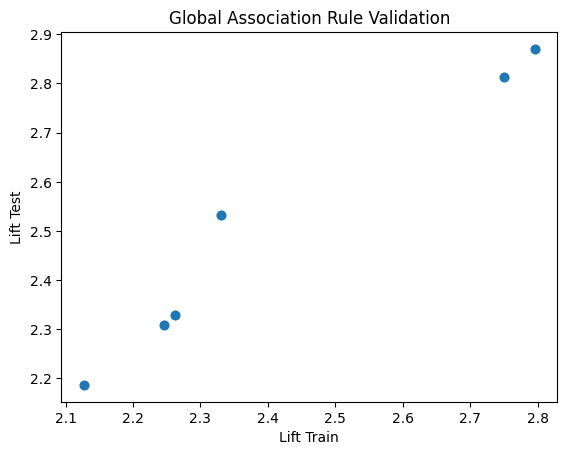

In [ ]:
plt.scatter(
    evaluation['lift_train'],
    evaluation['lift_test'],
)

plt.xlabel('Lift Train')
plt.ylabel('Lift Test')
plt.title('Global Association Rule Validation')
plt.show()

In [ ]:
print("Train rules:", len(rules_train))
print("Test rules:", len(rules_test))
print("Common rules:", len(evaluation))

Train rules: 16
Test rules: 14
Common rules: 12


In [ ]:
evaluation[['support_train', 'support_test', 
            'confidence_train', 'confidence_test', 
            'lift_train', 'lift_test']].describe().round(3)

,support_train,support_test,confidence_train,confidence_test,lift_train,lift_test
count,12.000,12.000,12.000,12.000,12.000,12.000
mean,0.022,0.023,0.235,0.243,2.419,2.507
std,0.002,0.002,0.048,0.049,0.270,0.270
min,0.020,0.020,0.202,0.209,2.127,2.187
25%,0.021,0.021,0.207,0.214,2.246,2.309
50%,0.022,0.023,0.216,0.222,2.296,2.430
75%,0.025,0.025,0.228,0.239,2.751,2.813
max,0.025,0.026,0.340,0.347,2.796,2.870


We can calculate the % absolute difference between the values to have a metric on how well our train and test scenarios approximate:

In [ ]:
mean_lift_perc_difference = (np.abs(evaluation['lift_train'] - evaluation['lift_test'])/evaluation['lift_train']).mean()

print(f"Mean absolute percentage difference in lift: {mean_lift_perc_difference:.2%}")

Mean absolute percentage difference in lift: 3.69%


## **Cluster-Specific Association Rules**

After validating the global association rules, we now generate association rules separately for each customer segment. This allows us to identify product associations that are more specific to each cluster and therefore more useful for targeted promotion strategies.

For each cluster, we filter the training baskets, encode the product lists, extract frequent itemsets with Apriori, and generate association rules using confidence and lift thresholds.

In [ ]:
train_baskets_df.head()

,invoice_id,list_of_goods,customer_id,basket_size,cluster_kmeans,cluster_name
1,10242376,"[low fat yogurt, tomatoes, pepper, asparagus, mint green tea, phone charger, ground beef, tomato sauce, red wine, soup, energy bar, fresh bread]",22853,12,4,Promotion Seekers
2,91550,"[cake, tomatoes, pancakes, iPad, final fantasy XIX, mineral water, ring light]",19,7,6,Protein Enjoyers
3,3137503,"[cereals, megaman zero, final fantasy XIX, honey]",10995,4,5,Large Families
4,7165061,"[rice, frozen smoothie, black tea, tea, minecraft, almonds, fresh bread, milk]",27807,8,5,Large Families
5,9814176,"[cottage cheese, samsung galaxy 10, strawberries, megaman zero, asparagus, bacon, metroid prime, oatmeal, sparkling water, flax seed, pet food, phone charger, tomato sauce, green grapes, red wine, whole wheat pasta, black beer]",36382,17,1,Vegetables-Hygiene Oriented


In [ ]:
cluster_0 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 0]
transactions_items_train_0, support_itemsets_train_0, rules_train_0 = generate_rules(cluster_0, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_0)
display(rules_train_0)

,support,itemsets
0,0.138499,frozenset({airpods})
3,0.106523,frozenset({asparagus})
18,0.095864,frozenset({butter})
5,0.094269,frozenset({babies food})
56,0.093184,frozenset({fresh bread})
...,...,...
97,0.042826,frozenset({mint})
34,0.041039,frozenset({cologne})
38,0.040082,frozenset({cottage cheese})
165,0.028083,"frozenset({airpods, energy drink})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({airpods}),frozenset({energy drink}),0.138499,0.089163,0.028083,0.202765,2.274103,1.0,0.015734,1.142495,0.650337,0.140710,0.124723,0.258863
1,frozenset({energy drink}),frozenset({airpods}),0.089163,0.138499,0.028083,0.314961,2.274103,1.0,0.015734,1.257594,0.615111,0.140710,0.204831,0.258863
3,frozenset({bluetooth headphones}),frozenset({airpods}),0.079334,0.138499,0.024955,0.314562,2.271221,1.0,0.013968,1.256861,0.607938,0.129385,0.204367,0.247373
2,frozenset({airpods}),frozenset({bluetooth headphones}),0.138499,0.079334,0.024955,0.180184,2.271221,1.0,0.013968,1.123016,0.649690,0.129385,0.109541,0.247373


In [ ]:
cluster_1 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 1]
transactions_items_train_1, support_itemsets_train_1, rules_train_1 = generate_rules(cluster_1, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_1)
display(rules_train_1)

,support,itemsets
43,0.151999,frozenset({dog food})
5,0.143291,frozenset({babies food})
101,0.128349,frozenset({napkins})
36,0.124433,frozenset({cooking oil})
23,0.111552,frozenset({cat food})
...,...,...
187,0.021486,"frozenset({cooking oil, pet food})"
194,0.021486,"frozenset({napkins, fresh bread})"
180,0.021434,"frozenset({cooking oil, chicken})"
177,0.021228,"frozenset({cooking oil, cereals})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
11,frozenset({cooking oil}),frozenset({napkins}),0.124433,0.128349,0.037047,0.297723,2.319631,1.0,0.021076,1.241177,0.649747,0.171722,0.194313,0.293181
10,frozenset({napkins}),frozenset({cooking oil}),0.128349,0.124433,0.037047,0.288639,2.319631,1.0,0.021076,1.230833,0.652666,0.171722,0.187542,0.293181
6,frozenset({cooking oil}),frozenset({babies food}),0.124433,0.143291,0.038850,0.312215,2.178883,1.0,0.021020,1.245606,0.617942,0.169743,0.197178,0.291670
7,frozenset({babies food}),frozenset({cooking oil}),0.143291,0.124433,0.038850,0.271125,2.178883,1.0,0.021020,1.201259,0.631544,0.169743,0.167540,0.291670
4,frozenset({napkins}),frozenset({babies food}),0.128349,0.143291,0.039468,0.307507,2.146025,1.0,0.021077,1.237137,0.612656,0.169996,0.191682,0.291474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,frozenset({dog food}),frozenset({chicken}),0.151999,0.104029,0.024371,0.160339,1.541287,1.0,0.008559,1.067062,0.414141,0.105205,0.062848,0.197307
18,frozenset({cat food}),frozenset({babies food}),0.111552,0.143291,0.024577,0.220323,1.537589,1.0,0.008593,1.098800,0.393530,0.106735,0.089916,0.195922
19,frozenset({babies food}),frozenset({cat food}),0.143291,0.111552,0.024577,0.171521,1.537589,1.0,0.008593,1.072385,0.408110,0.106735,0.067499,0.195922
48,frozenset({chicken}),frozenset({babies food}),0.104029,0.143291,0.021692,0.208519,1.455210,1.0,0.006786,1.082412,0.349134,0.096141,0.076137,0.179952


In [ ]:
cluster_3 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 3]
transactions_items_train_3, support_itemsets_train_3, rules_train_3 = generate_rules(cluster_3, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_3)
display(rules_train_3)

,support,itemsets
149,0.348051,frozenset({toothpaste})
133,0.346919,frozenset({shampoo})
41,0.345463,frozenset({deodorant})
134,0.344816,frozenset({shower gel})
148,0.342390,frozenset({tooth brush})
...,...,...
336,0.020055,"frozenset({energy bar, almonds, shampoo})"
529,0.020055,"frozenset({shower gel, razor, gluten free bar})"
167,0.020055,"frozenset({airpods, pancakes})"
325,0.020055,"frozenset({almonds, antioxydant juice, toothpaste})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
621,frozenset({bluetooth headphones}),frozenset({airpods}),0.065826,0.124212,0.033641,0.511057,4.114404,1.0,0.025464,1.791185,0.810289,0.215098,0.441711,0.390945
620,frozenset({airpods}),frozenset({bluetooth headphones}),0.124212,0.065826,0.033641,0.270833,4.114404,1.0,0.025464,1.281153,0.864309,0.215098,0.219453,0.390945
1547,frozenset({energy drink}),frozenset({bluetooth headphones}),0.081514,0.065826,0.020864,0.255952,3.888338,1.0,0.015498,1.255530,0.808745,0.164962,0.203524,0.286453
1546,frozenset({bluetooth headphones}),frozenset({energy drink}),0.065826,0.081514,0.020864,0.316953,3.888338,1.0,0.015498,1.344690,0.795163,0.164962,0.256334,0.286453
1642,frozenset({laptop}),frozenset({airpods}),0.047388,0.124212,0.020217,0.426621,3.434634,1.0,0.014331,1.527417,0.744110,0.133547,0.345300,0.294691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,frozenset({asparagus}),frozenset({shower gel}),0.061944,0.344816,0.022158,0.357702,1.037370,1.0,0.000798,1.020062,0.038403,0.057611,0.019668,0.210981
784,frozenset({oatmeal}),frozenset({energy bar}),0.117904,0.238881,0.028465,0.241427,1.010657,1.0,0.000300,1.003356,0.011954,0.086700,0.003345,0.180294
1470,frozenset({asparagus}),frozenset({deodorant}),0.061944,0.345463,0.021349,0.344648,0.997638,1.0,-0.000051,0.998755,-0.002517,0.055300,-0.001246,0.203223
816,frozenset({airpods}),frozenset({protein bar}),0.124212,0.233220,0.028142,0.226563,0.971453,1.0,-0.000827,0.991392,-0.032464,0.085462,-0.008683,0.173614


In [ ]:
cluster_4 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 4]
transactions_items_train_4, support_itemsets_train_4, rules_train_4 = generate_rules(cluster_4, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_4)
display(rules_train_4)

,support,itemsets
0,0.160555,frozenset({airpods})
3,0.117116,frozenset({asparagus})
80,0.089967,frozenset({laptop})
15,0.088965,frozenset({brownies})
12,0.086375,frozenset({bluetooth headphones})
...,...,...
168,0.022889,"frozenset({airpods, laptop})"
167,0.022805,"frozenset({airpods, iphone 10})"
170,0.022805,"frozenset({airpods, protein bar})"
169,0.020299,"frozenset({airpods, pancakes})"


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
9,frozenset({bluetooth headphones}),frozenset({energy drink}),0.086375,0.077187,0.020216,0.234043,3.032168,1.0,0.013549,1.204784,0.733565,0.141026,0.169976,0.247974
10,frozenset({energy drink}),frozenset({bluetooth headphones}),0.077187,0.086375,0.020216,0.261905,3.032168,1.0,0.013549,1.237814,0.726261,0.141026,0.192124,0.247974
2,frozenset({airpods}),frozenset({energy drink}),0.160555,0.077187,0.032996,0.205515,2.662577,1.0,0.020604,1.161524,0.743853,0.161159,0.139062,0.316502
3,frozenset({energy drink}),frozenset({airpods}),0.077187,0.160555,0.032996,0.427489,2.662577,1.0,0.020604,1.466252,0.676652,0.161159,0.317989,0.316502
0,frozenset({airpods}),frozenset({bluetooth headphones}),0.160555,0.086375,0.033665,0.209677,2.427513,1.0,0.019797,1.156015,0.700529,0.157854,0.134959,0.299713
1,frozenset({bluetooth headphones}),frozenset({airpods}),0.086375,0.160555,0.033665,0.389749,2.427513,1.0,0.019797,1.375573,0.643651,0.157854,0.273030,0.299713
8,frozenset({pancakes}),frozenset({airpods}),0.064489,0.160555,0.020299,0.314767,1.960496,1.0,0.009945,1.225051,0.523698,0.099143,0.183707,0.220599
6,frozenset({iphone 10}),frozenset({airpods}),0.074096,0.160555,0.022805,0.307779,1.916973,1.0,0.010909,1.212684,0.516624,0.107650,0.175383,0.224909
7,frozenset({protein bar}),frozenset({airpods}),0.074263,0.160555,0.022805,0.307087,1.912661,1.0,0.010882,1.211472,0.515447,0.107565,0.174558,0.224563
4,frozenset({energy bar}),frozenset({airpods}),0.082366,0.160555,0.023139,0.280933,1.749766,1.0,0.009915,1.167409,0.466956,0.105283,0.143402,0.212527


In [ ]:
cluster_5 = train_baskets_df[train_baskets_df['cluster_kmeans'] == 5]
transactions_items_train_5, support_itemsets_train_5, rules_train_5 = generate_rules(cluster_5, min_support=0.02, min_confidence=0.15)

display(support_itemsets_train_5)
display(rules_train_5)